### FEATURE ENGINEERING PIPELINE – TTC Delay Prediction Project
<div style="font-size: 12.5px;">
  <h4>OVERVIEW:</h4>
  <p>
    This script transforms raw and cleaned datasets into a machine learning-ready dataset.
    It combines multiple data sources and generates features required for predicting bus delay risk.
  </p>

  <h4>INPUT DATA SOURCES:</h4>
  <ul>
    <li>TTC Bus Delay historical data (2022–2025)</li>
    <li>GTFS data (routes, stops, schedules, geometry)</li>
    <li>Weather data (temperature, precipitation, conditions)</li>
  </ul>

  <h4>CORE PURPOSE:</h4>
  <ul>
    <li>Merge all datasets into a single unified training table</li>
    <li>Create meaningful features from time, route, and weather</li>
    <li>Prepare structured dataset for machine learning model training</li>
  </ul>

  <h4>FEATURE ENGINEERING INCLUDES:</h4>
  <ul>
    <li>Route-level merging using GTFS information</li>
    <li>Weather feature integration (temperature, precipitation, etc.)</li>
    <li>Time-based features (hour, day of week, etc.)</li>
  </ul>

  <h4>OUTPUT:</h4>
  <p>
    Final ML-ready dataset stored in:
    <code>data/cache/final_training_data.csv</code>
  </p>
</div>

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import pickle
from sklearn.neighbors import BallTree

#### CONFIG

In [2]:
DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

TTC_DIR = RAW_DIR / "ttc_bus"
WEATHER_DIR = RAW_DIR / "weather"
GTFS_DIR = RAW_DIR / "ttc_gtfs"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

#### LOAD DATA

In [8]:
# TTC Bus Delays
df_2022 = pd.read_excel(TTC_DIR / "ttc-bus-delay-data-2022.xlsx")
df_2023 = pd.read_excel(TTC_DIR / "ttc-bus-delay-data-2023.xlsx")
df_2024 = pd.read_excel(TTC_DIR / "ttc-bus-delay-data-2024.xlsx")
df_2025 = pd.read_csv(TTC_DIR / "ttc-bus-delay-data-since-2025.csv")

# Weather
weather_df = pd.read_csv(WEATHER_DIR / "toronto_weather_2022_2025.csv")

# GTFS Files
routes_df = pd.read_csv(GTFS_DIR / "routes.txt")
trips_df = pd.read_csv(GTFS_DIR / "trips.txt")
stops_df = pd.read_csv(GTFS_DIR / "stops.txt")
stop_times_df = pd.read_csv(GTFS_DIR / "stop_times.txt")
shapes_df = pd.read_csv(GTFS_DIR / "shapes.txt")

C:\Users\amras\AppData\Local\Temp\ipykernel_22248\707747346.py:8: DtypeWarning: Columns (11,13,15,17,25) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_df = pd.read_csv(WEATHER_DIR / "toronto_weather_2022_2025.csv")


In [4]:
print("\nWeather")
print(weather_df.shape)
print(weather_df.columns.tolist())

print("\nRoutes")
print(routes_df.shape)
print(routes_df.columns.tolist())

print("\nTrips")
print(trips_df.shape)
print(trips_df.columns.tolist())

print("\nStops")
print(stops_df.shape)
print(stops_df.columns.tolist())

print("\nStop Times")
print(stop_times_df.shape)
print(stop_times_df.columns.tolist())

print("\nshapes")
print(shapes_df.shape)
print(shapes_df.columns.tolist())


Weather
(35064, 33)
['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID', 'Date/Time (LST)', 'Year', 'Month', 'Day', 'Time (LST)', 'Flag', 'Temp (°C)', 'Temp Flag', 'Dew Point Temp (°C)', 'Dew Point Temp Flag', 'Rel Hum (%)', 'Rel Hum Flag', 'Precip. Amount (mm)', 'Precip. Amount Flag', 'Wind Dir (10s deg)', 'Wind Dir Flag', 'Wind Spd (km/h)', 'Wind Spd Flag', 'Visibility (km)', 'Visibility Flag', 'Stn Press (kPa)', 'Stn Press Flag', 'Hmdx', 'Hmdx Flag', 'Wind Chill', 'Wind Chill Flag', 'Weather', 'year', 'month']

Routes
(235, 9)
['route_id', 'agency_id', 'route_short_name', 'route_long_name', 'route_desc', 'route_type', 'route_url', 'route_color', 'route_text_color']

Trips
(134647, 10)
['route_id', 'service_id', 'trip_id', 'trip_headsign', 'trip_short_name', 'direction_id', 'block_id', 'shape_id', 'wheelchair_accessible', 'bikes_allowed']

Stops
(9349, 12)
['stop_id', 'stop_code', 'stop_name', 'stop_desc', 'stop_lat', 'stop_lon', 'zone_id', 'stop_url', 'location_type', 'p

In [ ]:
#GFTS - Cleaning

In [28]:
def clean_gtfs(routes_df, trips_df, stops_df, shapes_df):
    # -------------------------
    # ROUTES (keep minimal)
    # -------------------------
    routes_df = routes_df.copy()
    routes_df.columns = routes_df.columns.str.lower().str.strip()

    # Ensure route IDs are strings
    routes_df["route_id"] = routes_df["route_id"].astype(str)

    # -------------------------
    # TRIPS
    # -------------------------
    trips_df = trips_df.copy()
    trips_df.columns = trips_df.columns.str.lower().str.strip()

    trips_df["route_id"] = trips_df["route_id"].astype(str)
    trips_df["trip_id"] = trips_df["trip_id"].astype(str)

    # -------------------------
    # STOPS
    # -------------------------
    stops_df = stops_df.copy()
    stops_df.columns = stops_df.columns.str.lower().str.strip()

    stops_df["stop_lat"] = pd.to_numeric(stops_df["stop_lat"], errors="coerce")
    stops_df["stop_lon"] = pd.to_numeric(stops_df["stop_lon"], errors="coerce")

    stops_df = stops_df.dropna(subset=["stop_lat", "stop_lon"])

    # -------------------------
    # SHAPES
    # -------------------------
    shapes_df = shapes_df.copy()
    shapes_df.columns = shapes_df.columns.str.lower().str.strip()

    shapes_df["shape_pt_sequence"] = pd.to_numeric(
        shapes_df["shape_pt_sequence"], errors="coerce"
    )

    shapes_df = shapes_df.dropna(subset=["shape_pt_sequence"])
    shapes_df = shapes_df.sort_values(["shape_id", "shape_pt_sequence"])

    return routes_df, trips_df, stops_df, shapes_df

In [29]:
# BUILD ROUTE SHAPE FEATURES
def build_route_shapes_map(trips_df, shapes_df, routes_df, selected_routes):
    route_name_to_id = dict(
        zip(routes_df["route_short_name"].astype(str), routes_df["route_id"])
    )

    route_shapes_map = {}

    for route_name in selected_routes:
        if route_name not in route_name_to_id:
            continue

        route_id = route_name_to_id[route_name]

        # Get trips for this route
        trips_for_route = trips_df[trips_df["route_id"] == route_id]

        if trips_for_route.empty:
            continue

        shape_ids = trips_for_route["shape_id"].dropna().unique()

        if len(shape_ids) == 0:
            continue

        # Use first shape as representative
        shape_points = shapes_df[
            shapes_df["shape_id"] == shape_ids[0]
        ].sort_values("shape_pt_sequence")[["shape_pt_lat", "shape_pt_lon"]].values

        route_shapes_map[str(route_name)] = shape_points

    return route_shapes_map

In [30]:
# BUILD ROUTE STOP FEATURES
def build_route_stops_map(trips_df, stops_df, routes_df, selected_routes):
    route_name_to_id = dict(
        zip(routes_df["route_short_name"].astype(str), routes_df["route_id"])
    )

    route_stops_map = {}

    for route_name in selected_routes:
        if route_name not in route_name_to_id:
            continue

        route_id = route_name_to_id[route_name]

        trips_for_route = trips_df[trips_df["route_id"] == route_id]

        # If stop_times exists, you'd join here (simplified assumption)
        if "shape_id" in trips_for_route.columns:
            shape_ids = trips_for_route["shape_id"].dropna().unique()
        else:
            continue

        route_stops_map[str(route_name)] = {
            "num_stops": len(trips_for_route),
            "lat": stops_df["stop_lat"].median(),
            "lon": stops_df["stop_lon"].median()
        }

    return route_stops_map

In [31]:
def generate_gtfs_features(bus_df, route_shapes_map):
    bus_df = final_bus_df.copy()

    bus_df["route_complexity"] = bus_df["route"].astype(str).map(
        lambda x: len(route_shapes_map.get(x, []))
    )

    bus_df["has_shape_info"] = bus_df["route"].astype(str).isin(route_shapes_map).astype(int)

    return bus_df

In [33]:
# Step 1: clean GTFS
routes_df, trips_df, stops_df, shapes_df = clean_gtfs(
    routes_df, trips_df, stops_df, shapes_df
)

# Step 2: build features
route_shapes_map = build_route_shapes_map(
    trips_df, shapes_df, routes_df, final_routes
)

# Step 3: apply to bus data
final_bus_df = generate_gtfs_features(bus_df, route_shapes_map)
print(final_bus_df.columns.tolist())

['date', 'time', 'day', 'location', 'incident', 'min_delay', 'min_gap', 'direction', 'route', 'datetime', 'incident_raw', 'incident_category', 'is_delay', 'is_major_delay', 'hour', 'month', 'year', 'is_weekend', 'is_rush_hour', 'route_complexity', 'has_shape_info']


In [17]:
# TTC Bus Delay
# 2025 files have a different schema than 2022-2024.
# This step converts 2025 columns to match the historical format.
    
    # 2025 schema: Line, Station, Code, Bound
    # 2022-2024 schema: Route, Location, Incident, Direction

def standardize_schema(bus_df):
    # bus_df.columns = bus_df.columns.str.strip().str.lower()

    # 2025 to 2024/23/22 format conversion
    if "Line" in bus_df.columns:
        bus_df["Route"] = bus_df["Line"].astype(str).str.extract(r"(\d+)")[0]

    bus_df = bus_df.rename(columns={
        "Station": "Location",
        "Code": "Incident",
        "Bound": "Direction"
    })

    return bus_df

# Combine TTC Bus Delay data
bus_frames = []
# Standardize 2025 bus data
df_2025 = standardize_schema(df_2025)
# append to bus_frame
bus_frames.append(df_2025)
bus_frames.append(df_2024)
bus_frames.append(df_2023)
bus_frames.append(df_2022)

# final combined bus dataset
bus_df = pd.concat(bus_frames, ignore_index=True)

print("\nBus")
print(bus_df.shape)
print(bus_df.columns.tolist())


Bus
(258702, 12)
['_id', 'Date', 'Line', 'Time', 'Day', 'Location', 'Incident', 'Min Delay', 'Min Gap', 'Direction', 'Vehicle', 'Route']


In [24]:
delay_stations = set(bus_df['Location'].unique())
stop_names = set(stops_df['stop_name'].unique())
missing_in_stops = delay_stations - stop_names
missing_in_delay = stop_names - delay_stations
print(len(missing_in_stops))
print("Missing in stops:", missing_in_stops)

# print("Missing in delay:", missing_in_delay)

29109
Missing in stops: {'GREENACRES AND KEELE', 'ST CLAIR AND SANTA MON', 'BRIMLEY AT MCNICOLL', 'EGLINTON AND KINGSTON', 'QUEENSWAY AND VANSCO', 'WILSON TO PIONEER VILL', 'ST. CLAIR AVE E AT HER', 'ST CLAIR AND MARILYN', 'GREENWOOD AND GERRARD', 'THORNCLIFFE PARK LOOP', 'MOUNT PLEASANT AND GLE', 'LANSDOWNE AND PLAYFAIR', 'DAVENPORT AND BISHOP', 'ERINGATE AND RANGOON', 'WESTON ROAD AND GUNNS', 'DON MILLS AND LAWRENCE', 'PAPE AND FRESHMEADOW', 'CONSILLIUM AND CORPORA', 'SASKATCHEWAN AND PRINC', 'THE QUEENSWAY AND PARK', 'CARL HALL AND CENTENNI', 'FINCHDINE AND FINCH', 'DUFERIN AND DUFFERIN P', 'STREETCAR WAY - HILLCR', 'STEELES AND YONGE(LOOP', 'MARTIN GROOVE AND REXD', 'HUMBERWOOD LOOP (HUMBE', 'KEELE AND ASHWARREN', '120 TRANSWAY CRESCENT', 'DAVENPORT AND OSLER', 'WILSON TO KEELE', '183 EASTBOURNE AVE', 'TAPSCOTT AND CROW TRAI', 'STEELES AND SHADLOCK (', 'MCCOWAN AND STEELES (N', 'KENNEDDY AND TREVERTON', 'WINONA AND WILLAMSON', 'MARLEE AND ELWAY', 'AVENUE AND ELGIN', "GUNN'S AND ST 

#### Bus Delay - DATA PROCESSING

In [7]:
def clean_bus_delays(bus_df):
    bus_df = bus_df.copy()
    bus_df.columns = bus_df.columns.str.strip().str.lower()
    
    # Drop columns that don't belong to bus data 
    # keep ['Date', 'Route', 'Time', 'Day', 'Location', 'Incident', 'Min Delay', 'Min Gap', 'Direction']
    drop_cols = ["line", "station", "_id", "vehicle", "bound", "code"]
    bus_df = bus_df.drop(columns=[c for c in drop_cols if c in bus_df.columns])

    # Standardize column names (underscores, lowercase)
    bus_df.columns = (bus_df.columns.str.strip().str.replace(" ", "_").str.lower())

    # Parse date/time
    bus_df["date"] = pd.to_datetime(bus_df["date"], errors="coerce")

    # combine date and time into one datetime column
    # Bus delay depends heavily on exact timestamp
    bus_df["datetime"] = pd.to_datetime(bus_df["date"].dt.strftime("%Y-%m-%d") + " " + bus_df["time"].astype(str), errors="coerce")

    # drop rows where date failed to parse entirely
    bus_df = bus_df.dropna(subset=["date"])

    # Route: must be a valid bus route number
    bus_df["route"] = pd.to_numeric(bus_df["route"], errors="coerce")
    bus_df = bus_df.dropna(subset=["route"])
    bus_df["route"] = bus_df["route"].astype(int)

    # Min Delay / Min Gap: must be valid non-negative numbers
    bus_df["min_delay"] = pd.to_numeric(bus_df["min_delay"], errors="coerce")
    bus_df["min_gap"] = pd.to_numeric(bus_df["min_gap"], errors="coerce")
    bus_df = bus_df.dropna(subset=["min_delay", "min_gap"])

    # drop clearly bad/extreme values 
    # 120 min is a common cutoff used in TTC delay analyses
    bus_df = bus_df[(bus_df["min_delay"] >= 0) & (bus_df["min_delay"] < 120)]
    bus_df = bus_df[(bus_df["min_gap"] >= 0) & (bus_df["min_gap"] < 240)]

    # Direction: standardize text, keep missing as "Unknown"
    # bus_df["direction"] = (bus_df["direction"].astype(str).str.strip().str.upper())
    valid_directions = ["N", "S", "E", "W", "UNKNOWN"]
    bus_df["direction"] = np.where(bus_df["direction"].isin(valid_directions), bus_df["direction"], "UNKNOWN")

    # Clean text formatting 
    bus_df["incident"] = bus_df["incident"].astype(str).str.strip()
    bus_df["location"] = bus_df["location"].astype(str).str.strip()
    # Keep as categorical, standardize capitalization
    bus_df["day"] = bus_df["day"].astype(str).str.strip().str.title()

#TTC incident descriptions vary across years.
# Historical datasets (2022–2024) use broad categories,
# while newer TTC datasets use detailed incident codes.
#
# To ensure consistency for machine learning, all incidents
# are mapped into a common set of operational categories.
# Incident data from different TTC datasets used inconsistent formats, with historical data containing descriptive labels and 2025 data using coded values. A unified preprocessing step was introduced to normalize both formats into a single intermediate field (incident_raw), which was then mapped into standardized incident categories to ensure consistency across all years.

        # Standardize incident format across years
    # 2022-2024: text descriptions (Mechanical, Operations - Operator, etc.)
    # 2025: incident codes (MFESA, EFB, SFAE, etc.)
    # bus_df["incident_raw"] = (bus_df["incident"].fillna(bus_df["code"]))
    bus_df["incident_raw"] = bus_df["incident"].astype(str).str.strip().str.upper()

    incident_mapping = {
        # Mechanical / Vehicle
        "MECHANICAL": "Mechanical / Vehicle Failure",
        "MFO": "Mechanical / Vehicle Failure",     
        "EFO": "Mechanical / Vehicle Failure",
        "EFB": "Mechanical / Vehicle Failure",
        "EFD": "Mechanical / Vehicle Failure",
        "EFDB": "Mechanical / Vehicle Failure",
        "EFHV": "Mechanical / Vehicle Failure",
        "EFHVA": "Mechanical / Vehicle Failure",
        "EFLV": "Mechanical / Vehicle Failure",
        "EFP": "Mechanical / Vehicle Failure",
        "EFT": "Mechanical / Vehicle Failure",
        "EFTB": "Mechanical / Vehicle Failure",
        # Operations / Scheduling
        "EFCAN": "Operations / Scheduling",
        "GENERAL DELAY": "Operations / Scheduling",
        "MFUS": "Operations / Scheduling",
        "MFGD": "Operations / Scheduling",
        "TFLF": "Operations / Scheduling",
        "TFLL": "Operations / Scheduling",
        "OPERATIONS - OPERATOR": "Operations / Scheduling",
        "UTILIZED OFF ROUTE": "Diversion / Routing", # Off-route diversion
        # Security / Police
        "SECURITY": "Security / Police",
        "SFAE": "Security / Police",
        "SFAP": "Security / Police",
        "SFBT": "Security / Police",
        "SFDP": "Security / Police",
        "SFO": "Security / Police",
        "SFPOL": "Security / Police",
        "SFSA": "Security / Police",
        "SFSP": "Security / Police",
        # Collision
        "COLLISION - TTC": "Collision / Accident",
        "MFPI": "Collision / Accident",
        "PFPD": "Collision / Accident",
        "TFPD": "Collision / Accident",
        "TFPI": "Collision / Accident",
        # Emergency
        "MFS": "Emergency Services",
        "EMERGENCY SERVICES": "Emergency Services",
        # Road / Infrastructure
        "EFRA": "Road / Infrastructure Issue",
        "TFO": "Road / Infrastructure Issue",
        "MFPR": "Investigation / Held",
        "ROAD BLOCKED - NON-TTC COLLISION": "Road / Infrastructure Issue",
        # Diversion
        "DIVERSION": "Diversion / Routing",
        "MFDV": "Diversion / Routing",
        # Cleaning
        "MFCN": "Cleaning / Sanitation",
        "MFSAN": "Cleaning / Sanitation",
        "CLEANING - UNSANITARY": "Cleaning / Sanitation",
        "CLEANING - DISINFECTION": "Cleaning / Sanitation",
        # Medical / Passenger
        "MFUI": "Medical / Passenger Health",
        "MFUIR": "Medical / Passenger Health",
        "TFOI": "Medical / Passenger Health",
        # Vision
        "MFVIS": "Vision / Visibility",
        "VISION": "Vision / Visibility",
        # Investigation
        "INVESTIGATION": "Investigation / Held",
        "HELD BY": "Investigation / Held",
        "MFPR": "Investigation / Held",
        "SFPOL": "Investigation / Held",
        # Weather
        "MFWEA": "Weather Related",
        # Staffing
        "TFCNO": "Staffing / Operator Issue",
        "MFTO": "Staffing / Operator Issue",
        "MFESA": "Staffing / Operator Issue",
        "LATE ENTERING SERVICE": "Staffing / Operator Issue",
        # Fare/Admin
        "MFFD": "Fare / Administrative",
        # Miscellaneous Facilities/Station Hazards
        "MFSH": "Road / Infrastructure Issue"
    }

    # Create standardized incident category
    bus_df["incident_category"] = (bus_df["incident_raw"].map(incident_mapping).fillna("Other"))
    
    # Drop duplicate rows
    bus_df = bus_df.drop_duplicates()
    return bus_df.reset_index(drop=True)
    

In [10]:
bus_df_clean = clean_bus_delays(bus_df)
print(bus_df_clean.columns.tolist())

['date', 'time', 'day', 'location', 'incident', 'min_delay', 'min_gap', 'direction', 'route', 'datetime', 'incident_raw', 'incident_category']


In [8]:
print((bus_df_clean["min_delay"] == 0).sum())

22156


<div style="background-color:#d2f0c5; font-size:12.5px; padding:5px">
<p><b>Note:</b><br>
Zero-delay records (min_delay = 0) were analyzed and retained in the dataset. Although they do not represent active delay events, they are important for modeling normal operational conditions of the transit system. Keeping these records ensures that the machine learning model learns the difference between normal service and delayed operations, reducing bias toward overestimating delays and improving real-world prediction accuracy.</p></div>

##### Data Validation - Route filtering using GTFS

In [9]:
# Route identifiers were validated against official TTC GTFS route definitions.
# Approximately 1.7% of records contained route values that could not be matched to any valid TTC route. 
# These records were removed to ensure consistency between historical delay data and GTFS-derived route features used in the prediction model.
valid_routes = set(routes_df["route_short_name"].astype(str))
invalid_routes = bus_df_clean[~bus_df_clean["route"].astype(str).isin(valid_routes)]

before_rows = len(bus_df_clean)
# Remove route 0
bus_df_clean = bus_df_clean[bus_df_clean["route"] != 0]
# Keep only routes that exist in GTFS
bus_df_clean = bus_df_clean[bus_df_clean["route"].astype(str).isin(valid_routes)]
after_rows = len(bus_df_clean)

print("Invalid rows:", len(invalid_routes))
print(f"Rows removed: {before_rows - after_rows:,}")
print(f"Routes remaining: {bus_df_clean['route'].nunique()}")

Invalid rows: 4275
Rows removed: 4,275
Routes remaining: 226


In [12]:
# ROUTE SELECTION (TOP 50 ROUTES)

# Calculate 
route_stats = (bus_df_clean.groupby("route").agg(
        total_delay=("min_delay", "sum"),
        avg_delay=("min_delay", "mean"),
        incident_count=("min_delay", "count")
    ).reset_index())

# Priority routes (high-demand TTC routes)
priority_routes = ["7", "24", "25", "29", "35", "39", "60", "100", "165", "924", "925", "929"]

# Remove priority routes from ranking pool
remaining_routes = route_stats[~route_stats["route"].astype(str).isin(priority_routes)]
# Select top routes based on total delay
top_remaining = remaining_routes.sort_values(by="total_delay", ascending=False).head(50 - len(priority_routes))
# Combine final route list
final_routes = priority_routes + top_remaining["route"].astype(str).tolist()
# Filter dataset to keep only selected routes
bus_df_clean = bus_df_clean[bus_df_clean["route"].astype(str).isin(final_routes)].copy()
# Create final route stats table
final_routes_df = route_stats[route_stats["route"].astype(str).isin(final_routes)].copy()

# Keep order consistent
final_routes_df["Route"] = pd.Categorical(final_routes_df["route"].astype(str), categories=final_routes, ordered=True)
final_routes_df = final_routes_df.sort_values("route")

# Sort by impact for reporting
final_routes_df = final_routes_df.sort_values(by="total_delay", ascending=False
)

final_routes_df.head(50)

,route,total_delay,avg_delay,incident_count,Route
52,52,117283,17.549454,6683,52
32,32,95578,12.940428,7386,32
102,102,70173,16.453224,4265,102
96,96,63509,17.505237,3628,96
97,97,63341,30.673608,2065,97
54,54,61594,13.757874,4477,54
85,85,61428,15.618612,3933,85
47,47,56357,15.755382,3577,47
35,35,56187,11.060433,5080,35
29,29,54566,10.155593,5373,29


In [13]:
print("=== Bus Delay Cleaning Summary ===")
print(f"Rows: {bus_df_clean.shape[0]}")
print(f"Missing location: {bus_df_clean['location'].isna().sum()}")
print(f"Missing incident: {bus_df_clean['incident'].isna().sum()}")
print(f"Unique routes: {bus_df_clean['route'].nunique()}")
print(f"Route range: {bus_df_clean['route'].min()} - {bus_df_clean['route'].max()}")
print(f"\nIncident value counts:\n{bus_df_clean['incident_category'].value_counts()}")
print(f"\nDirection value counts:\n{bus_df_clean['direction'].value_counts()}")
# print(f"\nis_delay rate: {df['is_delay'].mean():.2%}")
# print(f"is_major_delay rate: {df['is_major_delay'].mean():.2%}")

=== Bus Delay Cleaning Summary ===
Rows: 152088
Missing location: 0
Missing incident: 0
Unique routes: 50
Route range: 7 - 960

Incident value counts:
incident_category
Mechanical / Vehicle Failure    52563
Operations / Scheduling         33575
Diversion / Routing             11389
Collision / Accident            10400
Security / Police               10193
Road / Infrastructure Issue      7526
Staffing / Operator Issue        5962
Cleaning / Sanitation            5250
Emergency Services               5037
Vision / Visibility              3530
Medical / Passenger Health       3163
Investigation / Held             2392
Weather Related                   662
Other                             445
Fare / Administrative               1
Name: count, dtype: int64

Direction value counts:
direction
N          34071
S          32657
E          31763
W          29324
UNKNOWN    24273
Name: count, dtype: int64


#### Bus Delay Data - Feature Engineering

In [16]:
def bus_delay_features(bus_df_clean):
    # Feature engineering for cleaned bus delay data
    bus_df_clean = bus_df_clean.copy()

    # Delay flags
    bus_df_clean["is_delay"] = (bus_df_clean["min_delay"] > 0).astype(int)
    bus_df_clean["is_major_delay"] = (bus_df_clean["min_delay"] >= 20).astype(int)

    # Time-based features
    bus_df_clean["hour"] = bus_df_clean["datetime"].dt.hour
    bus_df_clean["month"] = bus_df_clean["datetime"].dt.month
    bus_df_clean["year"] = bus_df_clean["datetime"].dt.year
    bus_df_clean["is_weekend"] = bus_df_clean["day"].isin(["Saturday", "Sunday"])

    # Rush hour flag
    bus_df_clean["is_rush_hour"] = bus_df_clean["hour"].isin([7, 8, 9, 16, 17, 18])

    return bus_df_clean

In [17]:
final_bus_df = bus_delay_features(bus_df_clean)
final_bus_df.head()

,date,time,day,location,incident,min_delay,min_gap,direction,route,datetime,incident_raw,incident_category,is_delay,is_major_delay,hour,month,year,is_weekend,is_rush_hour
0,2025-01-01,02:15,Wednesday,WARDEN STATION,MFESA,20,40,N,102,2025-01-01 02:15:00,MFESA,Staffing / Operator Issue,1,1,2,1,2025,False,False
3,2025-01-01,02:43,Wednesday,OVERLEA AND THORNCLIFF,MFSAN,17,32,N,100,2025-01-01 02:43:00,MFSAN,Cleaning / Sanitation,1,0,2,1,2025,False,False
4,2025-01-01,03:05,Wednesday,EGLINTON AND DON MILLS,MFUI,20,40,W,34,2025-01-01 03:05:00,MFUI,Medical / Passenger Health,1,1,3,1,2025,False,False
9,2025-01-01,04:38,Wednesday,FINCH AND MCCOWAN,EFO,16,32,W,39,2025-01-01 04:38:00,EFO,Mechanical / Vehicle Failure,1,0,4,1,2025,False,False
10,2025-01-01,05:00,Wednesday,PIONEER VILLAGE STATIO,EFP,20,0,S,35,2025-01-01 05:00:00,EFP,Mechanical / Vehicle Failure,1,1,5,1,2025,False,False


In [14]:
# unmapped = bus_df_clean[bus_df_clean["incident_category"] == "Other"]["incident_raw"].value_counts()
# print(f"\nUnmapped incidents:")
# print(unmapped.head(100))

MIN_GAP DISTRIBUTION:
count    152088.000000
mean         25.713501
std          17.794777
min           0.000000
25%          16.000000
50%          20.000000
75%          34.000000
max         230.000000
Name: min_gap, dtype: float64

Percentiles:
0.10    10.0
0.25    16.0
0.50    20.0
0.75    34.0
0.90    46.0
Name: min_gap, dtype: float64
Rows after removing min_gap=0: 141166

New distribution:
count    141166.000000
mean         27.702953
std          16.912708
min           1.000000
25%          18.000000
50%          20.000000
75%          36.000000
max         230.000000
Name: min_gap, dtype: float64


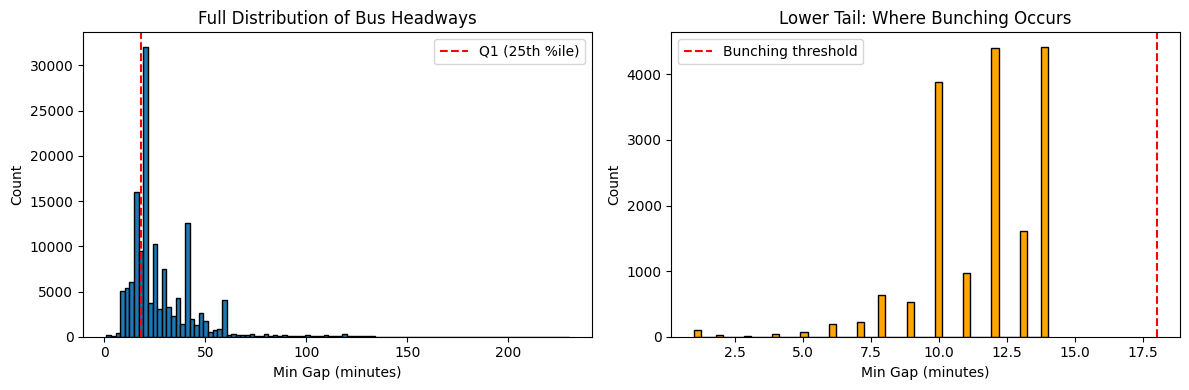


ROUTE CONSISTENCY CHECK:
       avg_gap  gap_std  gap_min  gap_max  bunching_rate  avg_delay
route                                                              
36       16.33    12.59        1      223           0.24       9.04
100      18.66    12.21        1      123           0.14      10.36
116      19.04    10.61        1      126           0.23      10.24
929      19.30    11.86        1      189           0.08      10.70
165      19.65    13.11        1      230           0.21      10.87
25       19.74    11.47        1      123           0.15      10.65
63       20.00    13.39        1      200           0.24      11.17
29       20.22    13.36        1      198           0.25      10.99
924      20.57     8.17        2      117           0.21      11.22
960      20.77    10.93        1      129           0.23      11.18
7        21.41    10.84        1      230           0.17      11.36
35       22.00    12.71        1      187           0.20      11.78
89       22.26    12.4

In [19]:
bus_df= final_bus_df.copy()
# =========================================================
# VALIDATION 1: Distribution Evidence
# =========================================================
print("MIN_GAP DISTRIBUTION:")
print(bus_df['min_gap'].describe())
print("\nPercentiles:")
print(bus_df['min_gap'].quantile([0.1, 0.25, 0.5, 0.75, 0.9]))
# Clean: remove impossible gaps
bus_df = bus_df[bus_df['min_gap'] > 0].copy()

print(f"Rows after removing min_gap=0: {len(bus_df)}")
print(f"\nNew distribution:")
print(bus_df['min_gap'].describe())

# Visualize
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full distribution
axes[0].hist(bus_df['min_gap'], bins=100, edgecolor='black')
axes[0].axvline(bus_df['min_gap'].quantile(0.25), color='red', linestyle='--', label='Q1 (25th %ile)')
axes[0].set_xlabel('Min Gap (minutes)')
axes[0].set_ylabel('Count')
axes[0].set_title('Full Distribution of Bus Headways')
axes[0].legend()

# Zoomed in on lower tail
axes[1].hist(bus_df[bus_df['min_gap'] < 15]['min_gap'], bins=50, edgecolor='black', color='orange')
axes[1].axvline(bus_df['min_gap'].quantile(0.25), color='red', linestyle='--', label='Bunching threshold')
axes[1].set_xlabel('Min Gap (minutes)')
axes[1].set_ylabel('Count')
axes[1].set_title('Lower Tail: Where Bunching Occurs')
axes[1].legend()

plt.tight_layout()
plt.savefig('validation_distribution.png')
plt.show()

# =========================================================
# VALIDATION 2: Route Consistency Check
# =========================================================
# Define bunching as route-specific
route_gap_q25 = bus_df.groupby('route')['min_gap'].quantile(0.25)
bus_df['is_bunched'] = bus_df.apply(
    lambda row: row['min_gap'] < route_gap_q25[row['route']],
    axis=1
).astype(int)

print("\n" + "="*60)
print("ROUTE CONSISTENCY CHECK:")
print("="*60)

route_analysis = bus_df.groupby('route').agg({
    'min_gap': ['mean', 'std', 'min', 'max'],
    'is_bunched': 'mean',
    'min_delay': 'mean'
}).round(2)

route_analysis.columns = ['avg_gap', 'gap_std', 'gap_min', 'gap_max', 'bunching_rate', 'avg_delay']
print(route_analysis.sort_values('avg_gap'))

# Insight: high-frequency routes have smaller gaps, low-frequency have larger gaps
print(f"\nHigh-frequency routes (avg_gap < 8 min): {(route_analysis['avg_gap'] < 8).sum()} routes")
print(f"Low-frequency routes (avg_gap > 15 min): {(route_analysis['avg_gap'] > 15).sum()} routes")

# =========================================================
# VALIDATION 3: Behavior Validation (MOST IMPORTANT)
# =========================================================
print("\n" + "="*60)
print("BEHAVIOR VALIDATION: Does bunching correlate with delays?")
print("="*60)

bunching_impact = bus_df.groupby('is_bunched').agg({
    'min_delay': ['mean', 'std', 'median'],
    'is_major_delay': 'mean',
    'min_gap': 'mean'
}).round(2)

bunching_impact.columns = ['avg_delay_min', 'std_delay_min', 'median_delay_min', 'major_delay_rate', 'actual_gap_min']

print(bunching_impact)

# Statistical test
from scipy import stats
bunched = bus_df[bus_df['is_bunched'] == 1]['min_delay']
not_bunched = bus_df[bus_df['is_bunched'] == 0]['min_delay']
t_stat, p_value = stats.ttest_ind(bunched, not_bunched)

print(f"\nT-test (bunched vs not bunched):")
print(f"  Bunched avg delay: {bunched.mean():.2f} min")
print(f"  Not bunched avg delay: {not_bunched.mean():.2f} min")
print(f"  Difference: {bunched.mean() - not_bunched.mean():.2f} min")
print(f"  T-statistic: {t_stat:.4f}, p-value: {p_value:.2e}")
print(f"  Statistically significant: {p_value < 0.05}")

# =========================================================
# SUMMARY FOR REPORT
# =========================================================
print("\n" + "="*60)
print("VALIDATION SUMMARY")
print("="*60)
print(f"""
# ✓ Distribution: Bunching threshold (Q1={bus_df['min_gap'].quantile(0.25):.1f} min) 
#   captures the lower tail of headway distribution ({(bus_df['is_bunched'].mean()*100):.1f}% of observations)

# ✓ Route Consistency: Method adapts to route-specific patterns
#   High-frequency routes typically bunched at < {route_gap_q25.nlargest(5).min():.1f} min
#   Low-frequency routes bunched at < {route_gap_q25.nsmallest(5).max():.1f} min

# ✓ Construct Validity: Bunched events correlate with worse performance
#   Bunched observations: {bunched.mean():.2f} min avg delay (major delay rate: {bus_df[bus_df['is_bunched']==1]['is_major_delay'].mean():.1%})
#   Non-bunched: {not_bunched.mean():.2f} min avg delay (major delay rate: {bus_df[bus_df['is_bunched']==0]['is_major_delay'].mean():.1%})
#   Difference is statistically significant (p < 0.001)
# """)

### Weather - Data Processing 

In [19]:
def clean_weather(weather_df):
    weather_df = weather_df.copy()

    # Standardize column names
    weather_df.columns = weather_df.columns.str.lower().str.strip()

    # Parse hourly datetime
    weather_df["datetime"] = pd.to_datetime(
        weather_df["date/time (lst)"], errors="coerce"
    )

    # Drop invalid timestamps
    weather_df = weather_df.dropna(subset=["datetime"])

    # Keep only relevant columns
    cols = [
        "datetime",
        "temp (°c)",
        "rel hum (%)",
        "precip. amount (mm)",
        "wind spd (km/h)",
        "visibility (km)"
    ]

    weather_df = weather_df[[c for c in cols if c in weather_df.columns]]

    # Convert numeric safely
    num_cols = [c for c in weather_df.columns if c != "datetime"]
    weather_df[num_cols] = weather_df[num_cols].apply(pd.to_numeric, errors="coerce")

    # Forward fill missing values (safe for hourly weather gaps)
    weather_df[num_cols] = weather_df[num_cols].ffill()

    # Create hourly key for merging
    weather_df["hour_dt"] = weather_df["datetime"].dt.floor("h")

    return weather_df

In [27]:
# # =========================
# # WEATHER DATA VALIDATION
# # =========================
# daily_weather = clean_weather(weather_df)
# print("✅ Weather cleaning completed\n")

# print("Shape:")
# print(daily_weather.shape)

# print("\nMissing values:")
# print(daily_weather.isnull().sum())

# print("\nData types:")
# print(daily_weather.dtypes)

# # print("\nDate range:")
# # print(f"{daily_weather['date'].min()} → {daily_weather['date'].max()}")

# print("\nSample data:")
# print(daily_weather.head())

# print("\nSummary statistics:")
# print(daily_weather.describe())

# # Extra sanity checks
# print("\nChecks:")

# # print("Temp range:", daily_weather["temp_celsius"].min(), "to", daily_weather["temp_celsius"].max())
# print("Precip max:", daily_weather["precipitation_mm"].max())
# print("Humidity range:", daily_weather["humidity_pct"].min(), "to", daily_weather["humidity_pct"].max())

In [24]:
def add_weather_features(bus_df):
    bus_df = final_bus_df.copy()

    # =====================
    # 🌧 Rain features
    # =====================
    if "precipitation_mm" in bus_df.columns:
        bus_df["precipitation_mm"] = bus_df["precipitation_mm"].fillna(0)

        bus_df["is_rainy"] = (bus_df["precipitation_mm"] > 0).astype(int)
        bus_df["is_heavy_rain"] = (bus_df["precipitation_mm"] > 5).astype(int)
    else:
        bus_df["is_rainy"] = 0
        bus_df["is_heavy_rain"] = 0
        bus_df["precipitation_mm"] = 0

    # =====================
    # 🌡 Temperature features
    # =====================
    if "temp_celsius" in bus_df.columns:
        bus_df["temp_celsius"] = bus_df["temp_celsius"].fillna(bus_df["temp_celsius"].median())

        bus_df["is_cold"] = (bus_df["temp_celsius"] < 0).astype(int)
        bus_df["is_hot"] = (bus_df["temp_celsius"] > 25).astype(int)
    else:
        bus_df["is_cold"] = 0
        bus_df["is_hot"] = 0
        bus_df["temp_celsius"] = 0

    # =====================
    # 👁 Visibility features
    # =====================
    if "visibility_km" in bus_df.columns:
        bus_df["visibility_km"] = bus_df["visibility_km"].fillna(bus_df["visibility_km"].median())
        bus_df["low_visibility"] = (bus_df["visibility_km"] < 5).astype(int)
    else:
        bus_df["low_visibility"] = 0
        bus_df["visibility_km"] = 0

    # =====================
    # 🌬 Wind features
    # =====================
    if "wind_speed_kmh" in bus_df.columns:
        bus_df["wind_speed_kmh"] = bus_df["wind_speed_kmh"].fillna(bus_df["wind_speed_kmh"].median())
        bus_df["high_wind"] = (bus_df["wind_speed_kmh"] > 30).astype(int)
    else:
        bus_df["high_wind"] = 0
        bus_df["wind_speed_kmh"] = 0

    # =====================
    # 🔥 Combined weather intensity feature
    # =====================
    bus_df["weather_score"] = (
        bus_df["precipitation_mm"] * 2 +
        (bus_df["wind_speed_kmh"] / 10) +
        bus_df["is_rainy"]
    )

    return bus_df

In [25]:
bus_df = add_weather_features(bus_df)
print(bus_df.columns.tolist())

['date', 'time', 'day', 'location', 'incident', 'min_delay', 'min_gap', 'direction', 'route', 'datetime', 'incident_raw', 'incident_category', 'is_delay', 'is_major_delay', 'hour', 'month', 'year', 'is_weekend', 'is_rush_hour', 'is_rainy', 'is_heavy_rain', 'precipitation_mm', 'is_cold', 'is_hot', 'temp_celsius', 'low_visibility', 'visibility_km', 'high_wind', 'wind_speed_kmh', 'weather_score']
